# MONTE-CARLO STUDY OF SOME ROBUST ESTIMATORS: 
Simple Linear Regression Case

In [1]:
# 1. Import necessary libraries
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

In [11]:
# 2. Define Experimental Parameters
PATH = Path(_dh[0]).resolve()  # Set path to parent directory   

Compute estimator functions for OLS, Theil's Pair-wise Median, LTS and Bayesian slope and intercept.

    x: independent variable array
    Y: response variable array

In [3]:
# 3. Define OLS function to estimate alpha and beta from simulated data

def OLS(X, Y):

    dev_x = X - np.mean(X)
    dev_x_squared = dev_x**2
    dev_y = Y - np.mean(Y)
    dev_xy = dev_x * dev_y

    beta_OLS = dev_xy.sum() / dev_x_squared.sum()
    alpha_OLS = np.mean(Y) - beta_OLS * np.mean(X)

    return alpha_OLS, beta_OLS

In [4]:
# 4A. Define Theil's pairwise median function to estimate alpha and beta from simulated data

def Theil_pm(X, Y):
    
    n = len(X)
    slopes = []

    for i in range(n):
        for j in range(i + 1, n):
            dx = X[j] - X[i]
            if dx != 0:
                slope = (Y[j] - Y[i]) / dx
                slopes.append(slope)

    beta_theil = np.median(slopes)

    # Conover's Intercept (alpha_con) 
    alpha_theil = np.median(Y) - beta_theil * np.median(X)

    return alpha_theil, beta_theil

In [5]:
# 4B. Define Theil's pairwise median function to estimate alpha and beta from simulated data. 
    # This vectorized version is significantly faster for Monte-Carlo simulations.

def Theil_pm_vec(x, y):
    
    # Create 2D matrices of all pairs (i, j)
    y_diff = y[:, np.newaxis] - y
    x_diff = x[:, np.newaxis] - x

    # Extract upper triangle indices to avoid duplicate pairs and self-pairs
    upper_tri_indices = np.triu_indices(len(x), k=1)
    
    delta_y = y_diff[upper_tri_indices]
    delta_x = x_diff[upper_tri_indices]

    # Calculate slopes and take the median. Filter out delta_x == 0 to avoid division by zero
    valid = delta_x != 0
    slopes = delta_y[valid] / delta_x[valid]
    
    beta_theil = np.median(slopes)
    
    # Conover's Intercept
    alpha_theil = np.median(y) - beta_theil * np.median(x)

    return alpha_theil, beta_theil

In [6]:
# 5. Define LTS function to estimate alpha and beta from simulated data

def LTS(X, Y, trim_pct=None): # trim_pct is the proportion of observations to drop (e.g., 20% means keeping the 80% with smallest residuals)
    
    n = len(X)
    alpha_OLS, beta_OLS = OLS(X, Y)

    residuals = Y - (alpha_OLS + beta_OLS * X)
    squared_residuals = residuals**2
    abs_residuals = np.abs(residuals)

    trim_level = int(trim_pct * n) if trim_pct is not None else int(0.20 * n)
    sorted_trimmed_ind = np.argsort(abs_residuals)[:n - trim_level]

    X_trimmed = X.iloc[sorted_trimmed_ind]
    Y_trimmed = Y.iloc[sorted_trimmed_ind]
    
    dev_x_trimmmed = X_trimmed - np.mean(X_trimmed)
    dev_x_trimmed_squared = dev_x_trimmmed**2
    dev_y_trimmed = Y_trimmed - np.mean(Y_trimmed)
    dev_xy_trimmed = dev_x_trimmmed * dev_y_trimmed
    
    beta_LTS = dev_xy_trimmed.sum() / dev_x_trimmed_squared.sum()
    alpha_LTS = np.mean(Y_trimmed) - beta_LTS * np.mean(X_trimmed)

    return alpha_LTS, beta_LTS

In [7]:
# 6. Define Bayesian Linear Estimator function to estimate alpha and beta from simulated data

def Bayesian_lm(X, Y, sigma_sq=1.0, beta_prior=None, alpha_prior=None):
    """
    Computes Bayesian Linear Regression parameters using a Conjugate Normal Prior.
    sigma_sq: variance of the error term (assumed known for the study)
    """
    n = len(X)
    x_bar = np.mean(X)
    y_bar = np.mean(Y)

    ss_x = np.sum((X - x_bar)**2)
    ss_xy = np.sum((X - x_bar) * (Y - y_bar))
    b_ols = ss_xy / ss_x # Least squares slope
    a_ols = y_bar        # Least squares intercept at the mean of X

    # Set Priors (Mean 0, 1)
    m_beta_prior = 0 if beta_prior is None else beta_prior
    s_beta_prior_sq = 1.0
    
    m_alpha_prior = 0 if alpha_prior is None else alpha_prior
    s_alpha_prior_sq = 1.0

    # Update Slope Posterior (Beta)
    precision_beta_post = (1 / s_beta_prior_sq) + (ss_x / sigma_sq)
    s_beta_post_sq = 1 / precision_beta_post
    m_beta_post = (s_beta_post_sq * (m_beta_prior / s_beta_prior_sq)) + \
                  (s_beta_post_sq * (ss_x * b_ols / sigma_sq))

    # Update Intercept Posterior (Alpha)
    precision_alpha_post = (1 / s_alpha_prior_sq) + (n / sigma_sq)
    s_alpha_post_sq = 1 / precision_alpha_post
    m_alpha_post = (s_alpha_post_sq * (m_alpha_prior / s_alpha_prior_sq)) + \
                   (s_alpha_post_sq * (n * a_ols / sigma_sq))

    # Transform intercept at mean to intercept at zero
    m_alpha_zero_post = m_alpha_post - (m_beta_post * x_bar)

    return m_alpha_zero_post, m_beta_post

Empirical Data Analysis

In [12]:
# 11. Load Empirical Data Files

data_path = PATH / r"country gdp gni popu.csv"

data = pd.read_csv(data_path)

print('\n',data.info(), '\n')
print('\n',data.describe(), '\n')
print(data.isna().sum())
print(data.shape)

null_data1 = data[(data['POPULATION 2024'] == 0) & (data['GDP(US$) 2024'] == 0)]
null_data2 = data[(data['POPULATION 2018'] == 0) & (data['GDP(US$) 2018'] == 0)]
print(null_data1)
print(null_data2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 268 entries, 0 to 267
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   COUNTRY          267 non-null    object 
 1   GDP(US$) 2024    266 non-null    float64
 2   POPULATION 2024  266 non-null    float64
 3   GDP(US$) 2018    266 non-null    float64
 4   POPULATION 2018  266 non-null    float64
dtypes: float64(4), object(1)
memory usage: 10.6+ KB

 None 


        GDP(US$) 2024  POPULATION 2024  GDP(US$) 2018  POPULATION 2018
count   2.660000e+02     2.660000e+02   2.660000e+02     2.660000e+02
mean    3.446859e+12     3.306237e+08   2.691209e+12     3.104160e+08
std     1.192360e+13     1.019971e+09   9.333646e+12     9.647652e+08
min     0.000000e+00     0.000000e+00   0.000000e+00     0.000000e+00
25%     8.720090e+09     1.651854e+06   7.874441e+09     1.661588e+06
50%     7.196710e+10     1.086537e+07   5.458166e+10     1.022952e+07
75%     6.077500e+11

In [13]:
data.drop(index=183, inplace=True)
null_data = data[(data['POPULATION 2024'] == 0) & (data['GDP(US$) 2024'] == 0)]
print(null_data)

Empty DataFrame
Columns: [COUNTRY, GDP(US$) 2024, POPULATION 2024, GDP(US$) 2018, POPULATION 2018]
Index: []


In [14]:
raw_data = data[['GDP(US$) 2024','POPULATION 2024']]
prior_data = data[['GDP(US$) 2018','POPULATION 2018']]

print('\n',raw_data, '\n')
print(raw_data.shape)
print('\n',prior_data, '\n')

# Check data structure and types
print('\n',raw_data.info(), '\n')
print('\n',raw_data.describe(), '\n')

print('\n',prior_data.info(), '\n')
print('\n',prior_data.describe(), '\n')


      GDP(US$) 2024  POPULATION 2024
0     0.000000e+00       42647492.0
1     1.240000e+12      769280888.0
2     7.360000e+11      521764076.0
3     2.704643e+10        2377128.0
4     2.690000e+11       46814308.0
..             ...              ...
263   0.000000e+00       40583164.0
264   2.530319e+10       21314956.0
265   4.153941e+10       16634373.0
266            NaN              NaN
267            NaN              NaN

[267 rows x 2 columns] 

(267, 2)

      GDP(US$) 2018  POPULATION 2018
0     1.805322e+10       36743039.0
1     1.020000e+12      657801085.0
2     7.780000e+11      452195915.0
3     1.537951e+10        2607733.0
4     1.950000e+11       42505035.0
..             ...              ...
263   2.160616e+10       34085182.0
264   2.631151e+10       17973569.0
265   3.414167e+10       15034452.0
266            NaN              NaN
267            NaN              NaN

[267 rows x 2 columns] 

<class 'pandas.core.frame.DataFrame'>
Index: 267 entries, 0 to 267
Data

In [15]:
raw_data = np.log1p(raw_data)
prior_data = np.log1p(prior_data)
size = raw_data.shape[0]
print(size)

quantiles = raw_data['GDP(US$) 2024'].quantile([0.1, 0.9])
stdev = raw_data['GDP(US$) 2024'].std()
trm_pct = 0.2

L1 = quantiles[0.1] - 2*stdev
L2 = quantiles[0.1] - 3*stdev

U1 = quantiles[0.9] + 2*stdev
U2 = quantiles[0.9] + 3*stdev

n_perturb = int(size * trm_pct)
quater_size = n_perturb // 4
over_size = n_perturb % 4

contaminant = np.ones(n_perturb)
contaminant[0:quater_size] = L1
contaminant[quater_size:2*quater_size] = L2
contaminant[2*quater_size:3*quater_size] = U1
contaminant[-(quater_size + over_size)] = U2

raw_data_contaminated = raw_data.copy()
raw_data_contaminated['GDP(US$) 2024'][-n_perturb:] = contaminant

raw_data_contaminated = raw_data_contaminated.sample(frac=1, random_state=42).reset_index(drop=True)

print(raw_data)
print('\n',raw_data_contaminated, '\n', contaminant, raw_data_contaminated.tail(n_perturb))

print(raw_data.isna().sum())
print(raw_data_contaminated.isna().sum())
print(stdev)

raw_data_contaminated.to_csv(PATH / r"raw_data_contaminated.csv", index=False)

267
     GDP(US$) 2024  POPULATION 2024
0         0.000000        17.568479
1        27.846132        20.460967
2        27.324496        20.072726
3        24.020821        14.681404
4        26.317977        17.661699
..             ...              ...
263       0.000000        17.518864
264      23.954196        16.874920
265      24.449908        16.626982
266            NaN              NaN
267            NaN              NaN

[267 rows x 2 columns]

      GDP(US$) 2024  POPULATION 2024
0        22.567573        12.548981
1        30.559545        21.066128
2        31.843149        21.057505
3        -4.408603        16.175508
4        23.712785        17.112547
..             ...              ...
262      25.053497        16.027364
263       0.000000         9.781094
264      24.487494        14.132029
265      24.227476        12.864905
266      24.336709        16.197434

[267 rows x 2 columns] 
 [ 3.56410601  3.56410601  3.56410601  3.56410601  3.56410601  3.56410601
  3.564

In [16]:
print(raw_data.describe())
print(raw_data_contaminated.describe())
print(prior_data.describe())

       GDP(US$) 2024  POPULATION 2024
count     265.000000       265.000000
mean       23.161099        16.216409
std         7.972709         3.088476
min         0.000000         9.174402
25%        22.946115        14.416740
50%        25.013342        16.204735
75%        27.135084        18.043098
max        32.340551        22.820278
       GDP(US$) 2024  POPULATION 2024
count     267.000000       265.000000
mean       21.183640        16.216409
std        12.228604         3.088476
min        -4.408603         9.174402
25%        21.403285        14.416740
50%        24.482470        16.204735
75%        27.206820        18.043098
max        53.078928        22.820278
       GDP(US$) 2018  POPULATION 2018
count     265.000000       265.000000
mean       24.512416        16.153721
std         4.737086         3.071259
min         0.000000         9.282847
25%        22.787437        14.401678
50%        24.728807        16.146083
75%        26.986664        17.912330
max        3

OLS Estimates: alpha = -2.259735668549588, beta = 1.567599439060283
LTS Estimates: alpha = 9.47620630878022, beta = 0.9607833344252754
THL Estimates: alpha = 9.501681007035678, beta = 0.9572301682674993
Bayes Estimates: alpha = -2.336716678691076, beta = 1.5669771811538191


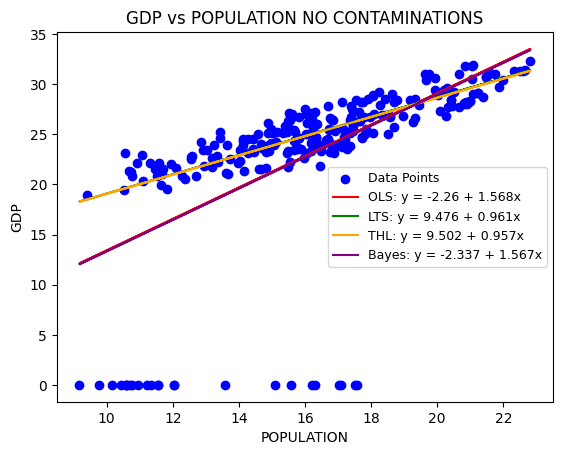

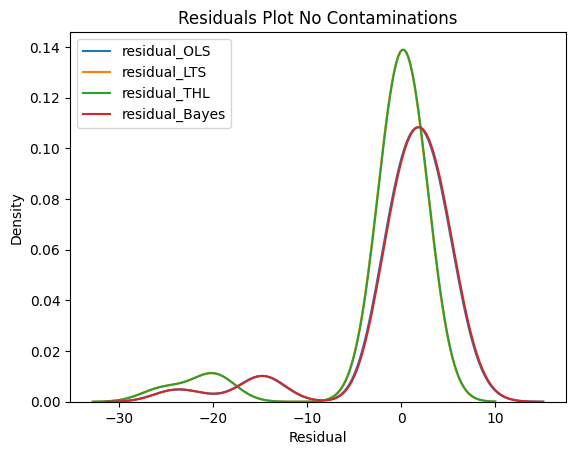

In [17]:
# 12. Analyze raw data with OLS, LTS, Theil's pairwise median, and Bayesian linear regression. Plot scatter graphs with trendlines and residual distributions.
valid_indices = raw_data['POPULATION 2024'].notna() & raw_data['GDP(US$) 2024'].notna()
raw_data = raw_data[valid_indices].reset_index(drop=True)

x = raw_data['POPULATION 2024']
y = raw_data['GDP(US$) 2024']

# Fit models and calculate residuals for each method
alpha_OLS,beta_OLS = OLS(x, y)
print(f'OLS Estimates: alpha = {alpha_OLS}, beta = {beta_OLS}')
y_trend_OLS = round(alpha_OLS,3) + round(beta_OLS,3) * x
raw_data['residual_OLS'] = y - y_trend_OLS

alpha_LTS,beta_LTS = LTS(x, y, trim_pct=0.20)
print(f'LTS Estimates: alpha = {alpha_LTS}, beta = {beta_LTS}')
y_trend_LTS = round(alpha_LTS,3) + round(beta_LTS,3) * x
raw_data['residual_LTS'] = y - y_trend_LTS

alpha_THL,beta_THL = Theil_pm(x, y)
print(f'THL Estimates: alpha = {alpha_THL}, beta = {beta_THL}')
y_trend_THL = round(alpha_THL,3) + round(beta_THL,3) * x
raw_data['residual_THL'] = y - y_trend_THL

alpha_Bayes,beta_Bayes = Bayesian_lm(x, y)
print(f'Bayes Estimates: alpha = {alpha_Bayes}, beta = {beta_Bayes}')
y_trend_Bayes = round(alpha_Bayes,3) + round(beta_Bayes,3) * x
raw_data['residual_Bayes'] = y - y_trend_Bayes

residuals = ['residual_OLS', 'residual_LTS', 'residual_THL', 'residual_Bayes']

# Plot scatter graph with trendlines for each method
plt.scatter(x, y, color='blue', label='Data Points')
plt.plot(x, y_trend_OLS, color='red', label=f'OLS: y = {round(alpha_OLS,3)} + {round(beta_OLS,3)}x')
plt.plot(x, y_trend_LTS, color='green', label=f'LTS: y = {round(alpha_LTS,3)} + {round(beta_LTS,3)}x')
plt.plot(x, y_trend_THL, color='orange', label=f'THL: y = {round(alpha_THL,3)} + {round(beta_THL,3)}x')
plt.plot(x, y_trend_Bayes, color='purple', label=f'Bayes: y = {round(alpha_Bayes,3)} + {round(beta_Bayes,3)}x')
plt.xlabel('POPULATION')
plt.ylabel('GDP')
plt.legend(fontsize=9)
plt.title('GDP vs POPULATION NO CONTAMINATIONS')
plt.grid(False)
plt.savefig('scatter_trends_raw.png', dpi=300, bbox_inches='tight')  # Save the figure
plt.show()

# Plot residual distributions for each method
for res in raw_data.columns:
    if res in residuals:
        sns.kdeplot(raw_data[res], label=res)
plt.xlabel('Residual')
plt.ylabel('Density')
plt.legend()
plt.title('Residuals Plot No Contaminations')
plt.savefig('residuals_raw.png', dpi=300, bbox_inches='tight')  # Save the figure
plt.show()


OLS Estimates: alpha = 3.410382676844165, beta = 1.1053980042947222
LTS Estimates: alpha = -2.315035890578695, beta = 1.6156613754765874
THL Estimates: alpha = 9.793856354980274, beta = 0.9067496860623401
Bayes Estimates: alpha = 3.337287819900016, beta = 1.1049592170440876


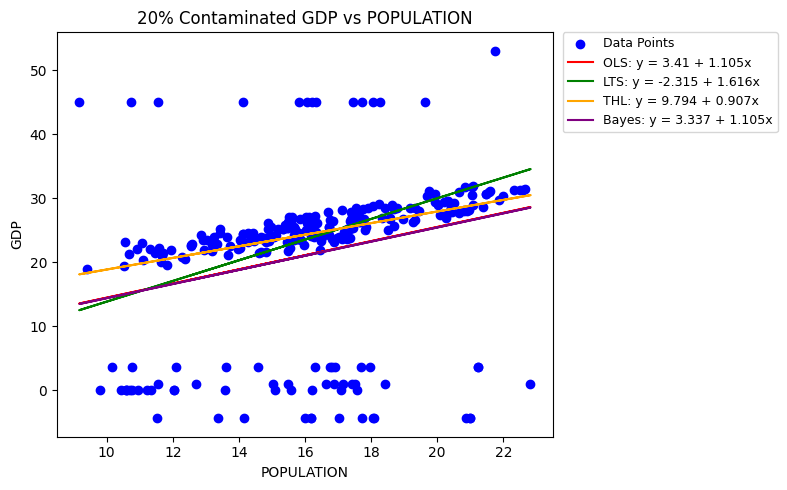

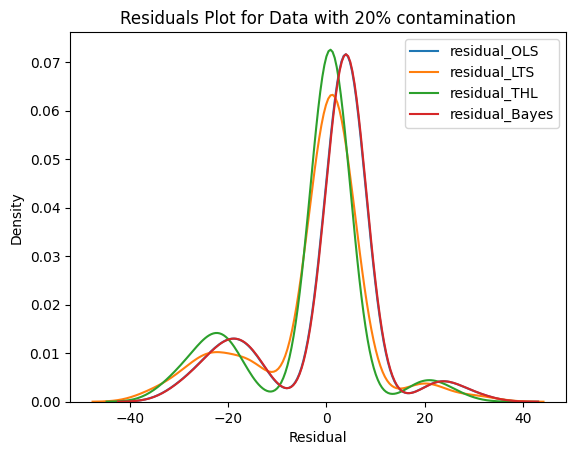

In [19]:
# Repeat the same analysis for the contaminated data
valid_indices = raw_data_contaminated['POPULATION 2024'].notna() & raw_data_contaminated['GDP(US$) 2024'].notna()
raw_data_contaminated = raw_data_contaminated[valid_indices].reset_index(drop=True)

x_cont = raw_data_contaminated['POPULATION 2024']
y_cont = raw_data_contaminated['GDP(US$) 2024']

alpha_OLS_cont,beta_OLS_cont = OLS(x_cont, y_cont)
print(f'OLS Estimates: alpha = {alpha_OLS_cont}, beta = {beta_OLS_cont}')
y_trend_OLS = round(alpha_OLS_cont,3) + round(beta_OLS_cont,3) * x_cont

alpha_LTS_cont,beta_LTS_cont = LTS(x_cont, y_cont, trim_pct=0.20)
print(f'LTS Estimates: alpha = {alpha_LTS_cont}, beta = {beta_LTS_cont}')
y_trend_LTS = round(alpha_LTS_cont,3) + round(beta_LTS_cont,3) * x_cont

alpha_THL_cont,beta_THL_cont = Theil_pm(x_cont, y_cont)
print(f'THL Estimates: alpha = {alpha_THL_cont}, beta = {beta_THL_cont}')
y_trend_THL = round(alpha_THL_cont,3) + round(beta_THL_cont,3) * x_cont 

alpha_Bayes_cont,beta_Bayes_cont = Bayesian_lm(x_cont, y_cont)
print(f'Bayes Estimates: alpha = {alpha_Bayes_cont}, beta = {beta_Bayes_cont}')
y_trend_Bayes = round(alpha_Bayes_cont,3) + round(beta_Bayes_cont,3) * x_cont  


raw_data_contaminated['residual_OLS'] = y_cont - y_trend_OLS
raw_data_contaminated['residual_LTS'] = y_cont - y_trend_LTS
raw_data_contaminated['residual_THL'] = y_cont - y_trend_THL
raw_data_contaminated['residual_Bayes'] = y_cont - y_trend_Bayes

residuals = ['residual_OLS', 'residual_LTS', 'residual_THL', 'residual_Bayes']

# 1. Set up the figure and axes
fig, ax = plt.subplots(figsize=(8, 5))

# Plot scatter graph with trendlines using the ax object directly
ax.scatter(x_cont, y_cont, color='blue', label='Data Points')
ax.plot(x_cont, y_trend_OLS, color='red', label=f'OLS: y = {round(alpha_OLS_cont,3)} + {round(beta_OLS_cont,3)}x')
ax.plot(x_cont, y_trend_LTS, color='green', label=f'LTS: y = {round(alpha_LTS_cont,3)} + {round(beta_LTS_cont,3)}x')
ax.plot(x_cont, y_trend_THL, color='orange', label=f'THL: y = {round(alpha_THL_cont,3)} + {round(beta_THL_cont,3)}x')
ax.plot(x_cont, y_trend_Bayes, color='purple', label=f'Bayes: y = {round(alpha_Bayes_cont,3)} + {round(beta_Bayes_cont,3)}x')

# Set labels and title on the ax object
ax.set_xlabel('POPULATION')
ax.set_ylabel('GDP')
ax.set_title('20% Contaminated GDP vs POPULATION')
ax.grid(False)

# Position the legend outside using standard matplotlib parameters
ax.legend(
    fontsize=9,
    loc="upper left",          # Anchor corner of the legend
    bbox_to_anchor=(1.02, 1),   # Shifts it right past the plot boundary
    borderaxespad=0
)

# Prevent the legend from getting clipped off the edge of the final image
plt.tight_layout()
plt.savefig('scatter_trends_contaminated.png', dpi=300, bbox_inches='tight')  # Save the figure
plt.show()

# Plot residual distributions for each method on contaminated data
for res in raw_data_contaminated.columns:
    if res in residuals:
        sns.kdeplot(raw_data_contaminated[res], label=res)
plt.xlabel('Residual')
plt.ylabel('Density')
plt.legend()
plt.title('Residuals Plot for Data with 20% contamination')
plt.savefig('residuals_contaminated.png', dpi=300, bbox_inches='tight')  # Save the figure
plt.show()

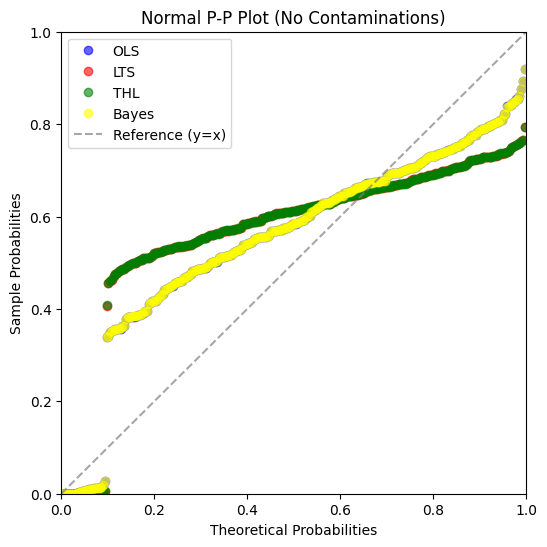

In [20]:
colors = ['blue','red','green','yellow']
residuals = ['residual_OLS', 'residual_LTS', 'residual_THL', 'residual_Bayes']

fig, ax = plt.subplots(figsize=(6, 6))
for i, res in enumerate(residuals):
    # Fallback to prevent IndexError if you have more than 4 residuals
    c = colors[i % len(colors)] 
    
    # 2. Verify the column actually exists in your DataFrame before plotting
    if res in raw_data.columns:
        pp_plot = sm.ProbPlot(raw_data[res], dist=stats.norm, fit=True)
        pp_plot.ppplot(ax=ax, marker='o', alpha=0.6, label=res.split('_')[1], markerfacecolor=c, markeredgecolor=c)

# 1. Draw a SINGLE clear reference line outside the loop
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', alpha=0.7, label='Reference (y=x)')

ax.set_title("Normal P-P Plot (No Contaminations)")

# 3. Add labels and legend
ax.set_xlabel("Theoretical Probabilities")
ax.set_ylabel("Sample Probabilities")
ax.legend(loc='best')
plt.savefig('ppplot_no_contaminations.png', dpi=300, bbox_inches='tight')
plt.show()

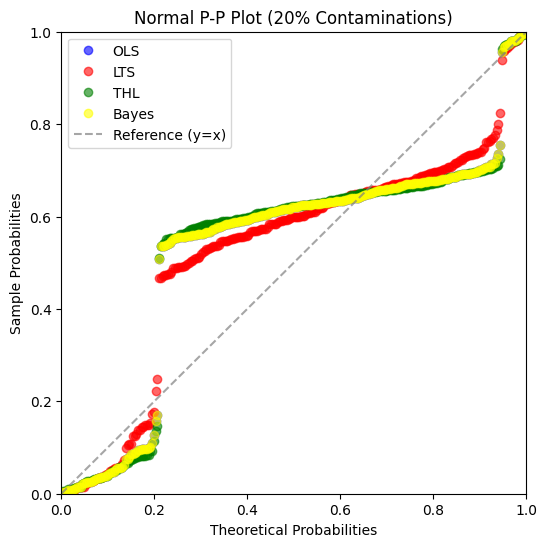

In [21]:
colors = ['blue','red','green','yellow']
residuals = ['residual_OLS', 'residual_LTS', 'residual_THL', 'residual_Bayes']

fig, ax = plt.subplots(figsize=(6, 6))
for i, res in enumerate(residuals):
    # Fallback to prevent IndexError if you have more than 4 residuals
    c = colors[i % len(colors)] 
    
    # 2. Verify the column actually exists in your DataFrame before plotting
    if res in raw_data_contaminated.columns:
        pp_plot = sm.ProbPlot(raw_data_contaminated[res], dist=stats.norm, fit=True)
        pp_plot.ppplot(ax=ax, marker='o', alpha=0.6, label=res.split('_')[1], markerfacecolor=c, markeredgecolor=c)

# 1. Draw a SINGLE clear reference line outside the loop
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', alpha=0.7, label='Reference (y=x)')

ax.set_title("Normal P-P Plot (20% Contaminations)")

# 3. Add labels and legend
ax.set_xlabel("Theoretical Probabilities")
ax.set_ylabel("Sample Probabilities")
ax.legend(loc='best')
plt.savefig('ppplot_20%_contaminations.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# 13. Systematic empirical data analysis (Data With No Contamination)
# Final tables to store results for each method, distribution, and sample size
final_table = []
samples = [10,50,raw_data.shape[0]]

# Lists to store estimates for each of the sample sizes
estimates = {'OLSE': [], 'LTS': [], 'Theil': [], 'Bayes': []}

beta_prior, alpha_prior, _, _, _ = stats.linregress(prior_data['POPULATION 2018'],prior_data['GDP(US$) 2018'])
print(f'prior slope: {beta_prior}; prior intercept: {alpha_prior}')

for ind, n in enumerate(samples):

    raw_data_subset = raw_data[0:n]
    x = raw_data_subset['POPULATION 2024']
    y = raw_data_subset['GDP(US$) 2024']

    x_bar = x.mean()
    y_bar = y.mean()
    x_sqd_dev = ((x-x_bar)**2).sum()

    # Run the four estimators (OLSE, LTS, Theil, Bayes)
    estimates['OLSE'].append(OLS(x, y))
    estimates['LTS'].append(LTS(x, y, trim_pct=0.20))
    estimates['Theil'].append(Theil_pm(x, y))
    estimates['Bayes'].append(Bayesian_lm(x, y, sigma_sq=1, beta_prior=beta_prior, alpha_prior=alpha_prior))

    # Calculate metrics: Mean, Bias, Variance, MSE, relative MSE (RMSE) compared to OLS for each method
    for method, values in estimates.items():
        # Convert to numpy array for easier calculation
        values = np.array(values) # Shape (150000, 2)
        
        alpha = values[ind, 0]
        beta = values[ind, 1]           
        y_cap = alpha  + beta * x
        sqd_res = (y-y_cap)**2
        var_res = sqd_res.sum()/(n-2)
        std_err = var_res**0.5
        
        bias_alpha = alpha_prior - alpha
        std_err_alpha = std_err * (((1/n) + (x_bar**2/x_sqd_dev))**0.5)
        bias_beta = beta_prior - beta
        std_err_beta = std_err/(x_sqd_dev**0.5)
        bias_model = y_bar - y_cap.mean()
        mse = var_res + (bias_model**2)

        if method != 'Bayesian_lm':
            LCL_beta = float(beta - 1.96 * std_err_beta)
            UCL_beta = float(beta + 1.96 * std_err_beta)
            confidence_interval_beta = (LCL_beta, UCL_beta)

            LCL_alpha = float(alpha - 1.96 * std_err_beta)
            UCL_alpha = float(alpha + 1.96 * std_err_beta)
            confidence_interval_Alpha = (LCL_alpha, UCL_alpha)

            interval_beta = confidence_interval_beta
            interval_alpha = confidence_interval_Alpha

        elif method == 'Bayesian_lm':
            LCrL_beta = beta - 1.96 * std_err_beta
            UCrL_beta = beta + 1.96 * (s_beta_post_sq/n)**0.5
            Credible_interval_beta = (LCrL_beta, UCrL_beta)
                    
            LCrL_Alpha = alpha - 1.96 * std_err_alpha
            UCrL_Alpha = alpha + 1.96 * std_err_alpha
            Credible_interval_alpha = (LCrL_Alpha, UCrL_Alpha)

            interval_beta = Credible_interval_beta
            interval_alpha = Credible_interval_alpha
                        
        # Store results for table construction
        final_table.append({
        'Sample Size': n,   
        'Method': method,
        'True_Beta': round(beta,4),
        'Bias (Beta)': round(bias_beta,4),
        'Standard Error (Beta)': round(std_err_beta,4),
        'True_Alpha': round(alpha,4),
        'Bias (Alpha)': round(bias_alpha,4),
        'Standard Error (Alpha)': round(std_err_alpha,4),
        'MSE (Model)': round(mse,4),
        'Bias (Model)': round(bias_model,4),
        'Credible Interval (Beta)': [round(interval_beta[0],4), round(interval_beta[1],4)],
        'Credible Interval (Alpha)': [round(interval_alpha[0],4), round(interval_alpha[1],4)],
                })

        print(f'================= Sample Size = {n} =================')
        Final_Table = pd.DataFrame(final_table).sort_values(by=['Sample Size', 'MSE (Model)'], ascending=[True, True]).reset_index(drop=True)
        print(Final_Table)

# Convert to DataFrame for easy visualization
emp_results = pd.DataFrame(final_table).sort_values(by=['Sample Size', 'MSE (Model)'], ascending=[True, True]).reset_index(drop=True)
emp_results.to_csv(f'Empirical_Results.csv', index=False)
print(emp_results)


prior slope: 0.9974520212996898; prior intercept: 8.399790363883206
[[-0.49346062  1.29080891]]
================= Sample Size = 10 =================
   Sample Size Method  True_Beta  Bias (Beta)  Standard Error (Beta)  \
0           10   OLSE     1.2908      -0.2934                 0.9068   

   True_Alpha  Bias (Alpha)  Standard Error (Alpha)  MSE (Model)  \
0     -0.4935        8.8933                 15.0028     108.2679   

   Bias (Model) Credible Interval (Beta) Credible Interval (Alpha)  
0          -0.0        [-0.4865, 3.0681]         [-2.2707, 1.2838]  
[[13.76064389  0.70133023]]
================= Sample Size = 10 =================
   Sample Size Method  True_Beta  Bias (Beta)  Standard Error (Beta)  \
0           10   OLSE     1.2908      -0.2934                 0.9068   
1           10    LTS     0.7013       0.2961                 1.0387   

   True_Alpha  Bias (Alpha)  Standard Error (Alpha)  MSE (Model)  \
0     -0.4935        8.8933                 15.0028     108.2679 

In [ ]:
# 14. Systematic empirical data analysis (Data With 20% Contamination)
# Final tables to store results for each method, distribution, and sample size
final_table = []
samples = [10,50,raw_data_contaminated.shape[0]]

# Lists to store estimates for each of the sample sizes
estimates = {'OLSE': [], 'LTS': [], 'Theil': [], 'Bayes': []}

beta_prior, alpha_prior, _, _, _ = stats.linregress(prior_data['POPULATION 2018'],prior_data['GDP(US$) 2018'])
print(f'prior slope: {beta_prior}; prior intercept: {alpha_prior}')

for ind, n in enumerate(samples):

    raw_data_subset = raw_data_contaminated[0:n]
    x = raw_data_subset['POPULATION 2024']
    y = raw_data_subset['GDP(US$) 2024']

    x_bar = x.mean()
    y_bar = y.mean()
    x_sqd_dev = ((x-x_bar)**2).sum()

    # Run the four estimators (OLSE, LTS, Theil, Bayes)
    estimates['OLSE'].append(OLS(x, y))
    estimates['LTS'].append(LTS(x, y, trim_pct=0.20))
    estimates['Theil'].append(Theil_pm(x, y))
    estimates['Bayes'].append(Bayesian_lm(x, y, sigma_sq=1, beta_prior=beta_prior, alpha_prior=alpha_prior))

    # Calculate metrics: Mean, Bias, Variance, MSE, relative MSE (RMSE) compared to OLS for each method
    for method, values in estimates.items():
        # Convert to numpy array for easier calculation
        values = np.array(values) # Shape (150000, 2)
        
        alpha = values[ind, 0]
        beta = values[ind, 1]           
        y_cap = alpha  + beta * x
        sqd_res = (y-y_cap)**2
        var_res = sqd_res.sum()/(n-2)
        std_err = var_res**0.5
        
        bias_alpha = alpha_prior - alpha
        std_err_alpha = std_err * (((1/n) + (x_bar**2/x_sqd_dev))**0.5)
        bias_beta = beta_prior - beta
        std_err_beta = std_err/(x_sqd_dev**0.5)
        bias_model = y_bar - y_cap.mean()
        mse = var_res + (bias_model**2)

        if method != 'Bayesian_lm':
            LCL_beta = float(beta - 1.96 * std_err_beta)
            UCL_beta = float(beta + 1.96 * std_err_beta)
            confidence_interval_beta = (LCL_beta, UCL_beta)

            LCL_alpha = float(alpha - 1.96 * std_err_beta)
            UCL_alpha = float(alpha + 1.96 * std_err_beta)
            confidence_interval_Alpha = (LCL_alpha, UCL_alpha)

            interval_beta = confidence_interval_beta
            interval_alpha = confidence_interval_Alpha

        elif method == 'Bayesian_lm':
            LCrL_beta = beta - 1.96 * std_err_beta
            UCrL_beta = beta + 1.96 * (s_beta_post_sq/n)**0.5
            Credible_interval_beta = (LCrL_beta, UCrL_beta)
                    
            LCrL_Alpha = alpha - 1.96 * std_err_alpha
            UCrL_Alpha = alpha + 1.96 * std_err_alpha
            Credible_interval_alpha = (LCrL_Alpha, UCrL_Alpha)

            interval_beta = Credible_interval_beta
            interval_alpha = Credible_interval_alpha
                        
        # Store results for table construction
        final_table.append({
        'Sample Size': n,   
        'Method': method,
        'True_Beta': round(beta,4),
        'Bias (Beta)': round(bias_beta,4),
        'Standard Error (Beta)': round(std_err_beta,4),
        'True_Alpha': round(alpha,4),
        'Bias (Alpha)': round(bias_alpha,4),
        'Standard Error (Alpha)': round(std_err_alpha,4),
        'MSE (Model)': round(mse,4),
        'Bias (Model)': round(bias_model,4),
        'Credible Interval (Beta)': [round(interval_beta[0],4), round(interval_beta[1],4)],
        'Credible Interval (Alpha)': [round(interval_alpha[0],4), round(interval_alpha[1],4)],
                })

        print(f'================= Sample Size = {n} =================')
        Final_Table = pd.DataFrame(final_table).sort_values(by=['Sample Size', 'MSE (Model)'], ascending=[True, True]).reset_index(drop=True)
        print(Final_Table)

# Convert to DataFrame for easy visualization
emp_results = pd.DataFrame(final_table).sort_values(by=['Sample Size', 'MSE (Model)'], ascending=[True, True]).reset_index(drop=True)
emp_results.to_csv(f'Empirical_Results_cont.csv', index=False)
print(emp_results)


prior slope: 0.9974520212996898; prior intercept: 8.399790363883206
[[17.02208572  0.23898267]]
================= Sample Size = 10 =================
   Sample Size Method  True_Beta  Bias (Beta)  Standard Error (Beta)  \
0           10   OLSE      0.239       0.7585                 1.5816   

   True_Alpha  Bias (Alpha)  Standard Error (Alpha)  MSE (Model)  \
0     17.0221       -8.6223                 26.5287     138.7742   

   Bias (Model) Credible Interval (Beta) Credible Interval (Alpha)  
0          -0.0        [-2.8609, 3.3388]        [13.9222, 20.1219]  
[[12.19056229  0.84655888]]
================= Sample Size = 10 =================
   Sample Size Method  True_Beta  Bias (Beta)  Standard Error (Beta)  \
0           10   OLSE     0.2390       0.7585                 1.5816   
1           10    LTS     0.8466       0.1509                 1.7806   

   True_Alpha  Bias (Alpha)  Standard Error (Alpha)  MSE (Model)  \
0     17.0221       -8.6223                 26.5287     138.7742 